# Solar Panel Thermal Analysis

Layer 2 of 3. Loads cached view factors, solves the transient two-sided temperature of each solar panel leaf for HOT and COLD back-face brackets, and exports the temperature traces for use in `background.ipynb`.

**Requires:** `outputs/viewfactor/` (from `run_viewfactor.ipynb`).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from geometry import RealizedGeometry
from thermal import (
    SOLAR_PANEL_CELL_ALPHA_SOLAR, SOLAR_PANEL_CELL_EPSILON,
    SOLAR_PANEL_BACK_HOT, SOLAR_PANEL_BACK_COLD,
    SOLAR_PANEL_SUBSTRATE_AREAL_CAPACITANCE,
    radiative_background, transient_temperature,
    save_temperatures,
)
from viewfactor import load_profiles

# ── Paths ──────────────────────────────────────────────────────────────────
from config import SPACECRAFT_JSON as GEOMETRY_FILE, VF_NPZ, VF_META_JSON, PANEL_TEMP_NPZ

# ── Solver config ──────────────────────────────────────────────────────────
N_ORBITS = 10    # integration orbits for convergence
TOL_K    = 0.5  # orbit-to-orbit max-delta convergence tolerance [K]

In [2]:
# ── Load ───────────────────────────────────────────────────────────────────
realized = RealizedGeometry.from_json(GEOMETRY_FILE)
profiles, meta = load_profiles(VF_NPZ, meta_path=VF_META_JSON)
by_name      = {p.surface_name: p for p in profiles}
orbit_period = meta['orbit_period']

panel_fronts = sorted(
    [s for s in realized.by_tag('solar_panel')
     if np.allclose(s.normal, [0.0, 0.0, 1.0], atol=1e-9)],
    key=lambda s: float(s.center[1]),
)
panel_backs = [realized.by_name(s.name + '_back') for s in panel_fronts]

print(f'Orbit period: {orbit_period:.1f} s  ({orbit_period / 60:.1f} min)')
print(f'Panels: {[s.name for s in panel_fronts]}')

Orbit period: 5615.0 s  (93.6 min)
Panels: ['wing_starboard_outer', 'wing_starboard_inner', 'wing_port_inner', 'wing_port_outer']


In [3]:
# ── Transient solve — HOT bracket (Clear-Hard Anodised back face) ──────────
solver_base = dict(
    alpha_front=SOLAR_PANEL_CELL_ALPHA_SOLAR,
    epsilon_front=SOLAR_PANEL_CELL_EPSILON,
    thermal_capacitance=SOLAR_PANEL_SUBSTRATE_AREAL_CAPACITANCE,
    orbit_period=orbit_period,
    n_orbits=N_ORBITS,
    tol=TOL_K,
)

panel_temps_hot = {}
for front, back in zip(panel_fronts, panel_backs):
    print(f'HOT  {front.name}...', end=' ', flush=True)
    bg_f = radiative_background(by_name[front.name], solar_panel_temperature_K=0.0)
    bg_b = radiative_background(by_name[back.name],  solar_panel_temperature_K=0.0)
    th   = transient_temperature(
        bg_f, bg_b,
        alpha_back=SOLAR_PANEL_BACK_HOT.alpha,
        epsilon_back=SOLAR_PANEL_BACK_HOT.epsilon,
        **solver_base,
    )
    panel_temps_hot[front.name] = th.temperature
    print(f'{th.temperature.min():.1f} – {th.temperature.max():.1f} K')

HOT  wing_starboard_outer... 242.0 – 362.6 K
HOT  wing_starboard_inner... 241.7 – 362.6 K
HOT  wing_port_inner... 241.9 – 362.6 K
HOT  wing_port_outer... 242.0 – 362.7 K


In [4]:
# ── Transient solve — COLD bracket (Surtec 650 back face) ─────────────────
panel_temps_cold = {}
for front, back in zip(panel_fronts, panel_backs):
    print(f'COLD {front.name}...', end=' ', flush=True)
    bg_f = radiative_background(by_name[front.name], solar_panel_temperature_K=0.0)
    bg_b = radiative_background(by_name[back.name],  solar_panel_temperature_K=0.0)
    th   = transient_temperature(
        bg_f, bg_b,
        alpha_back=SOLAR_PANEL_BACK_COLD.alpha,
        epsilon_back=SOLAR_PANEL_BACK_COLD.epsilon,
        **solver_base,
    )
    panel_temps_cold[front.name] = th.temperature
    print(f'{th.temperature.min():.1f} – {th.temperature.max():.1f} K')

COLD wing_starboard_outer... 207.3 – 332.3 K
COLD wing_starboard_inner... 206.1 – 331.5 K
COLD wing_port_inner... 206.0 – 331.5 K
COLD wing_port_outer... 207.4 – 332.3 K


In [5]:
# ── Area-weighted array temperature trace + save ───────────────────────────
panel_areas = np.array([s.width * s.height for s in panel_fronts])

def array_mean(temps_dict):
    traces = np.stack([temps_dict[s.name].mean(axis=(1, 2)) for s in panel_fronts])
    return np.average(traces, axis=0, weights=panel_areas)

array_hot  = array_mean(panel_temps_hot)
array_cold = array_mean(panel_temps_cold)

panel_data = {
    s.name: {'hot': panel_temps_hot[s.name], 'cold': panel_temps_cold[s.name]}
    for s in panel_fronts
}
PANEL_TEMP_NPZ.parent.mkdir(exist_ok=True, parents=True)
save_temperatures(panel_data, PANEL_TEMP_NPZ)

print(f'Saved {len(panel_data)} panel temperature fields → {PANEL_TEMP_NPZ}')
print(f'Array temp HOT:  {array_hot.min():.1f} – {array_hot.max():.1f} K')
print(f'Array temp COLD: {array_cold.min():.1f} – {array_cold.max():.1f} K')

Saved 4 panel temperature fields → outputs\thermal\ISST45_2416_360.npz
Array temp HOT:  241.9 – 362.5 K
Array temp COLD: 207.5 – 329.2 K


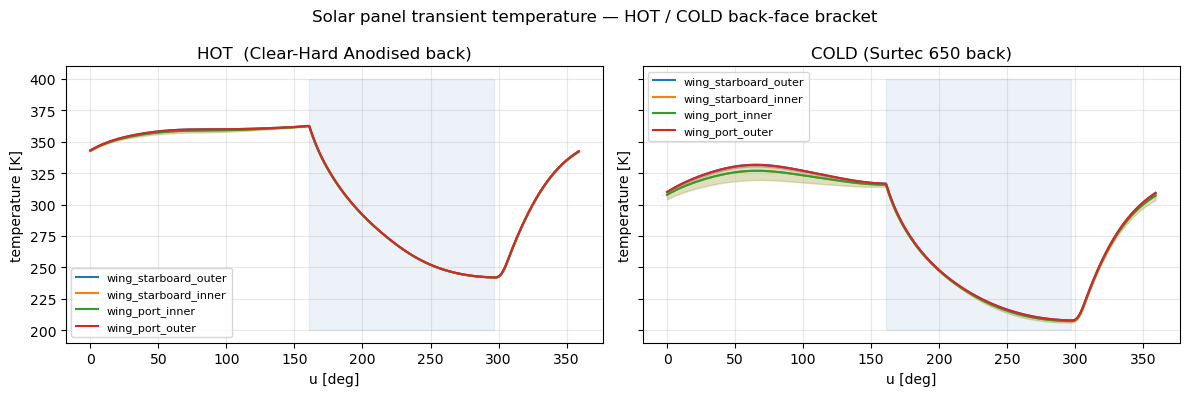

In [6]:
# ── Figure: per-panel temperature orbit traces ─────────────────────────────
u_deg   = np.degrees(profiles[0].u)
eclipse = profiles[0].eclipse

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, temps, bracket in [
    (axes[0], panel_temps_hot,  'HOT  (Clear-Hard Anodised back)'),
    (axes[1], panel_temps_cold, 'COLD (Surtec 650 back)'),
]:
    ax.fill_between(u_deg, 200, 400, where=eclipse, alpha=0.1, color='steelblue')
    prop_cycle = iter(plt.rcParams['axes.prop_cycle'])
    for s in panel_fronts:
        t = temps[s.name]
        mean = t.mean(axis=(1, 2))
        lo, hi = t.min(axis=(1, 2)), t.max(axis=(1, 2))
        c = next(prop_cycle)['color']
        ax.fill_between(u_deg, lo, hi, alpha=0.15, color=c)
        ax.plot(u_deg, mean, lw=1.5, color=c, label=s.name)
    ax.set_xlabel('u [deg]')
    ax.set_ylabel('temperature [K]')
    ax.set_title(bracket)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Solar panel transient temperature — HOT / COLD back-face bracket')
plt.tight_layout()
plt.show()